In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = [10, 6]


In [3]:
# Load and combine datasets
# Replace "/content/drive/MyDrive/2.Murdoch Uni/S1.2025/ICT607/datasets/Assignment-BETH/"
# by the actual path of your Google Drive
csv_files = glob.glob("/content/drive/MyDrive/2.Murdoch Uni/S1.2025/ICT607/datasets/Assignment-BETH/*[!dns].csv")
df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)


In [4]:
# Understanding the dataset
print("Data shape:\n", df.shape)
print("\nData description:\n", df.describe())
print("\nDataset info:\n")
df.info()
# print("Columns and datatype:\n", df.dtypes)

print("\nSome first rows:\n", df.head())

Data shape:
 (3807196, 16)

Data description:
         timestamp   processId  parentProcessId      userId     eventId  \
count 3807196.000 3807196.000      3807196.000 3807196.000 3807196.000   
mean     6962.757    6958.577         3081.929      47.850     299.045   
std      5750.655    2213.023         3075.620     210.156     393.640   
min       123.746       1.000            0.000       0.000       2.000   
25%      1392.407    7354.000         1197.000       0.000       3.000   
50%      5597.048    7522.000         1341.000       0.000      59.000   
75%     12371.052    7780.000         7096.000       0.000     257.000   
max     18887.205    8910.000         8908.000    1001.000    1010.000   

          argsNum  returnValue         sus        evil    threadId  \
count 3807196.000  3807196.000 3807196.000 3807196.000 1141078.000   
mean        2.707       14.946       0.120       0.044    6913.038   
std         1.316      357.457       0.325       0.206    1807.393   
min   

In [5]:
# Check the data with null
print(df.isna().sum())


timestamp                0
processId                0
parentProcessId          0
userId                   0
processName              0
hostName                 0
eventId                  0
eventName                0
argsNum                  0
returnValue              0
args                     0
sus                      0
evil                     0
threadId           2666118
mountNamespace     2666118
stackAddresses     2666118
dtype: int64


<Axes: xlabel='sus,evil'>

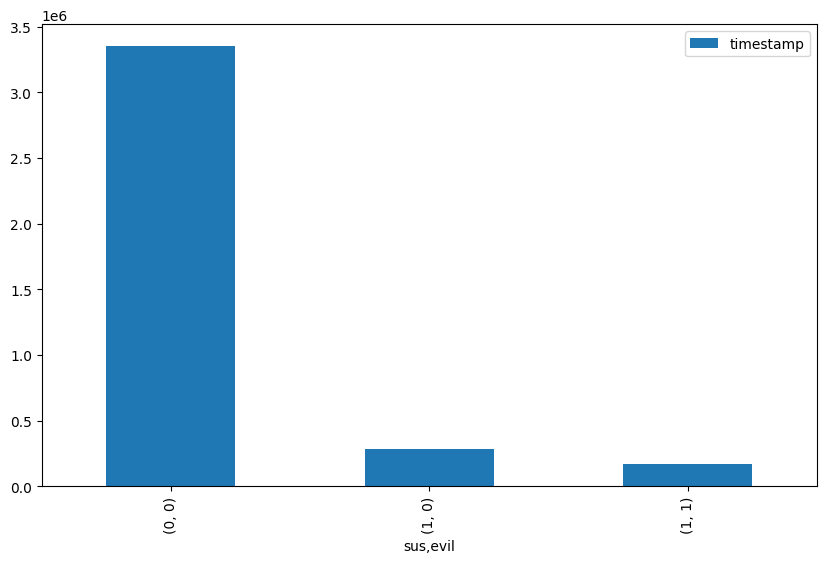

In [6]:
# Show the innsight of target label
df.groupby(['sus', 'evil'])[['timestamp']].count()
df.groupby(['sus', 'evil'])[['timestamp']].count().plot(kind='bar')


In [7]:
# Separate numeric columns and categories columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("Numeric columns:\n", numeric_columns)
print("\nCatagorical columns:\n", categorical_columns)

Numeric columns:
 Index(['timestamp', 'processId', 'parentProcessId', 'userId', 'eventId',
       'argsNum', 'returnValue', 'sus', 'evil', 'threadId', 'mountNamespace'],
      dtype='object')

Catagorical columns:
 Index(['processName', 'hostName', 'eventName', 'args', 'stackAddresses'], dtype='object')


In [8]:
# Handling missing value
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())
df[categorical_columns] = df[categorical_columns].fillna(df[categorical_columns].mode().iloc[0])

# check the dataset again
print(df.isna().sum())

timestamp          0
processId          0
parentProcessId    0
userId             0
processName        0
hostName           0
eventId            0
eventName          0
argsNum            0
returnValue        0
args               0
sus                0
evil               0
threadId           0
mountNamespace     0
stackAddresses     0
dtype: int64


In [9]:
# Check the unique value of categorical columns
for col in categorical_columns:
    unique_values = df[col].unique()
    print(f"Unique values in column: {df[col].nunique()} \n '{col}': \n{unique_values}")

Unique values in column: 308 
 'processName': 
['systemd-udevd' 'systemd-timesyn' 'systemd-resolve' 'sleep'
 'terraform_21167' 'sshd' 'systemd-logind' 'bash' 'scp' 'accounts-daemon'
 'cron' 'dbus-daemon' 'systemd-journal' 'systemd' 'docker' 'dockerd'
 'containerd-shim' 'amazon-ssm-agen' 'ps' '(sd-pam)' '(time-dir)'
 'systemd-user-ru' 'systemd-network' 'snapd' 'dns' 'journal-offline'
 'kworker/dying' 'ssm-agent-worke' 'packagekitd' 'gmain' 'gdbus' 'sh'
 'run-parts' '(tmpfiles)' 'systemd-tmpfile' 'close' 'atd' '(otd-news)'
 '50-motd-news' 'mktemp' 'awk' 'dpkg' 'dpkg-query' 'sed' 'uname' 'grep'
 'cloud-id' 'cut' 'tr' 'wget' 'head' 'cat' 'rm' '(t-helper)' 'apt-helper'
 'systemctl' '(md.daily)' 'apt.systemd.dai' 'apt-config' 'flock' 'cmp'
 'cp' 'savelog' 'date' 'basename' 'which' 'dirname' 'mv' 'apt-get' 'http'
 'https' 'gpgv' 'apt-key' 'chmod' 'readlink' 'touch' 'find' 'sort'
 'gpgconf' 'gpg-connect-age' 'store' 'test' '(kagekitd)' 'pool-packagekit'
 'echo' 'cnf-update-db' 'update-motd-upd

In [10]:
# Encoding categorical features
categories_columns_dict_encode = {}
for col in categorical_columns:
    categories_columns_dict_encode[col] = LabelEncoder()
    df[col] = categories_columns_dict_encode[col].fit_transform(df[col])
# check categorical data
print(df[categorical_columns])

         processName  hostName  eventName     args  stackAddresses
0                131        16         22  1402629          112473
1                131        16         22  1402633          112473
2                131        16         22  1402659          112473
3                131        16         22  1402656          112473
4                131        16         22  1402664          112473
...              ...       ...        ...      ...             ...
3807191          294         7         10  1415140          112473
3807192          294         7         10  1415161          112473
3807193          294         7         10  1415183          112473
3807194          294         7         10  1415205          112473
3807195          294         7         10  1415225          112473

[3807196 rows x 5 columns]


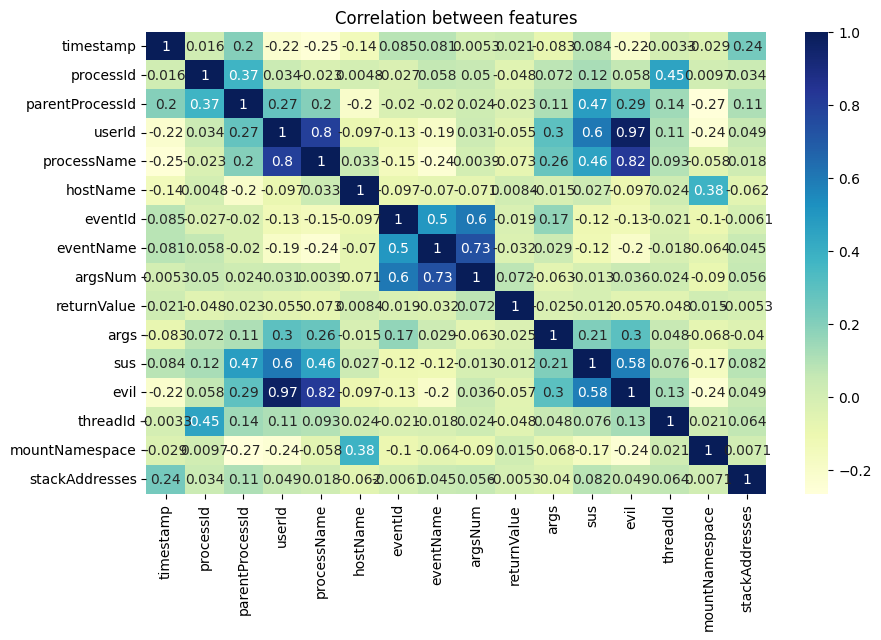

In [11]:
# Checking correlation between features.
corr = df.corr()
fig, ax = plt.subplots()
sns.heatmap(corr, ax = ax, annot=True, cmap="YlGnBu")
ax.set_title("Correlation between features")
plt.show()

In [12]:
df.corr().unstack().sort_values(ascending=False).drop_duplicates()

timestamp        timestamp         1.000
userId           evil              0.969
evil             processName       0.819
processName      userId            0.798
eventName        argsNum           0.734
                                   ...  
processName      eventName        -0.239
mountNamespace   userId           -0.241
                 evil             -0.241
timestamp        processName      -0.251
parentProcessId  mountNamespace   -0.266
Length: 121, dtype: float64

In [13]:
# Dropping the correlated features 'processName', 'argsNum', and 'eventID'
df = df.drop(['processName', 'argsNum', 'eventId'], axis=1)

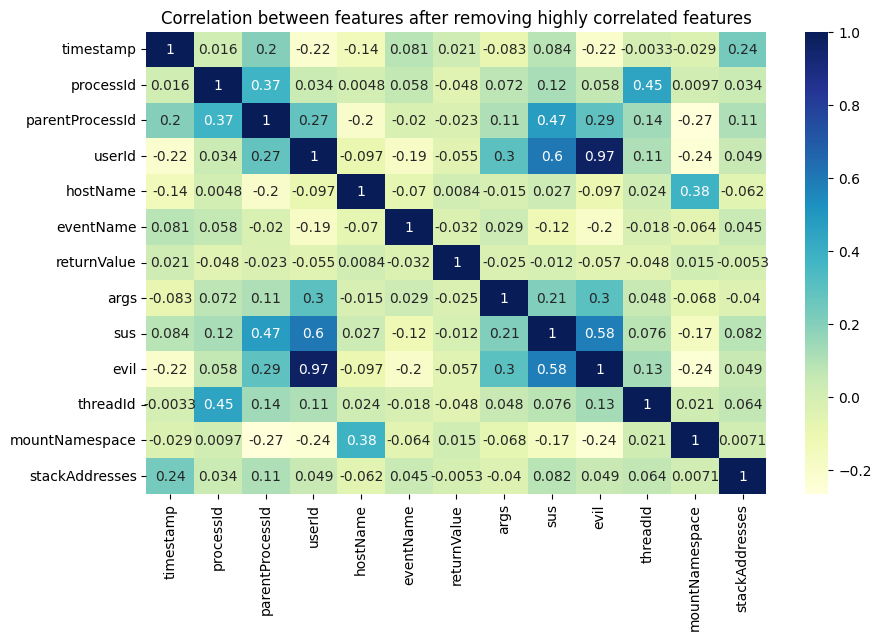

In [14]:
# Double check the correlation before training the model
corr = df.corr()
fig, ax = plt.subplots()
sns.heatmap(corr, ax = ax, annot=True, cmap="YlGnBu")
ax.set_title("Correlation between features after removing highly correlated features")
plt.show()

In [15]:
# X: features dataset and Y: target dataset
X = df.drop(['evil', 'sus'], axis=1)
Y = df['evil']
print("Predictors' shape: ", X.shape)
print("Label's shape: ", Y.shape)

Predictors' shape:  (3807196, 11)
Label's shape:  (3807196,)


In [16]:
# Scale feature: MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
# Checking after scaling
X_scaled

array([[6.96120570e-05, 2.13267482e-02, 1.12258644e-04, ...,
        8.02046653e-01, 2.51038624e-01, 1.00000000e+00],
       [6.96144553e-05, 2.13267482e-02, 1.12258644e-04, ...,
        8.02046653e-01, 2.51038624e-01, 1.00000000e+00],
       [6.96187722e-05, 2.13267482e-02, 1.12258644e-04, ...,
        8.02046653e-01, 2.51038624e-01, 1.00000000e+00],
       ...,
       [1.98728313e-02, 8.47906611e-01, 8.47328244e-01, ...,
        8.76537480e-01, 0.00000000e+00, 1.00000000e+00],
       [1.98728324e-02, 8.47906611e-01, 8.47328244e-01, ...,
        8.76537480e-01, 0.00000000e+00, 1.00000000e+00],
       [1.98728336e-02, 8.47906611e-01, 8.47328244e-01, ...,
        8.76537480e-01, 0.00000000e+00, 1.00000000e+00]])

In [18]:
# Split data: training data 80%, testing data 20%
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)


In [19]:
# Checking data after spliting
print("X_train: ", X_train.shape)
print("Y_train: ", Y_train.shape)

print("X_test: ", X_test.shape)
print("Y_test: ", Y_test.shape)

X_train:  (3045756, 11)
Y_train:  (3045756,)
X_test:  (761440, 11)
Y_test:  (761440,)


In [20]:
# Train Random Forest Model
rf = RandomForestClassifier(n_estimators=20, random_state=42)
rf.fit(X_train, Y_train)

RandomForestClassifier(n_estimators=20, random_state=42)

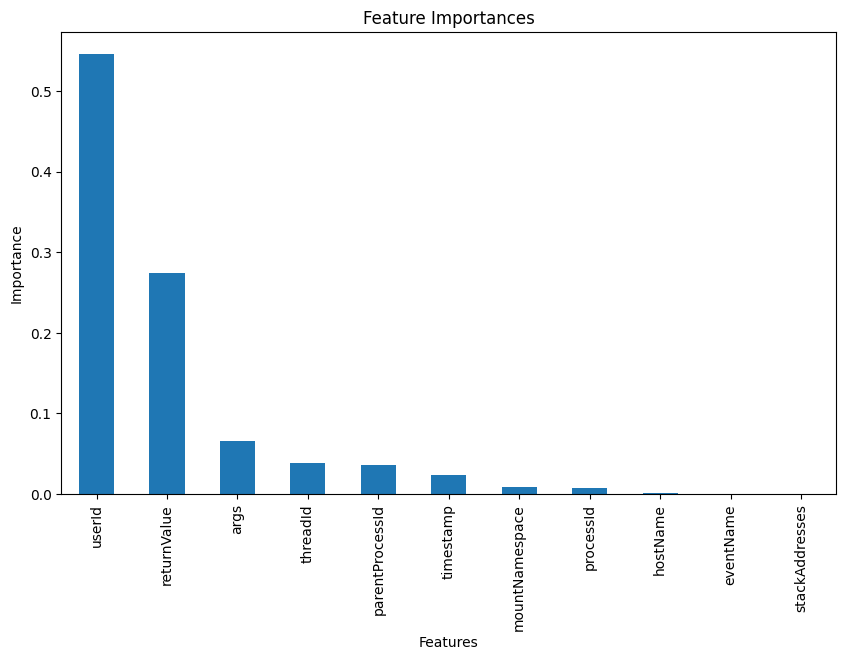

In [21]:
# Compute mutual information scores
importances = rf.feature_importances_
feature_names = X.columns
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
forest_importances.plot(kind='bar')
plt.title('Feature Importances')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()

In [22]:
# Make prediction
Y_pred = rf.predict(X_test)
print(Y_pred)

[0 0 0 ... 0 0 0]


Accuracy: 0.9999855536877496
Confusion matrix:
 [[727772      7]
 [     4  33657]]


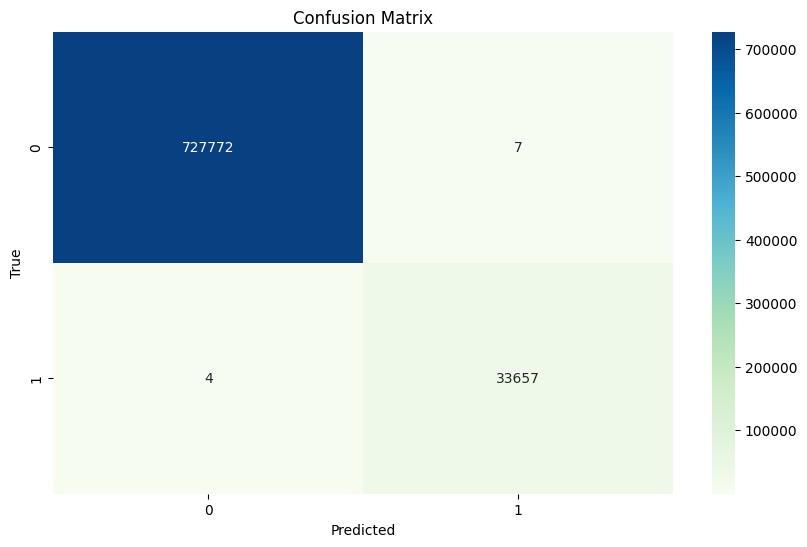

Precision: 1.00
Recall: 1.00
F1 Score: 1.00
ROC AUC Score: 1.00
ROC AUC: 1.00


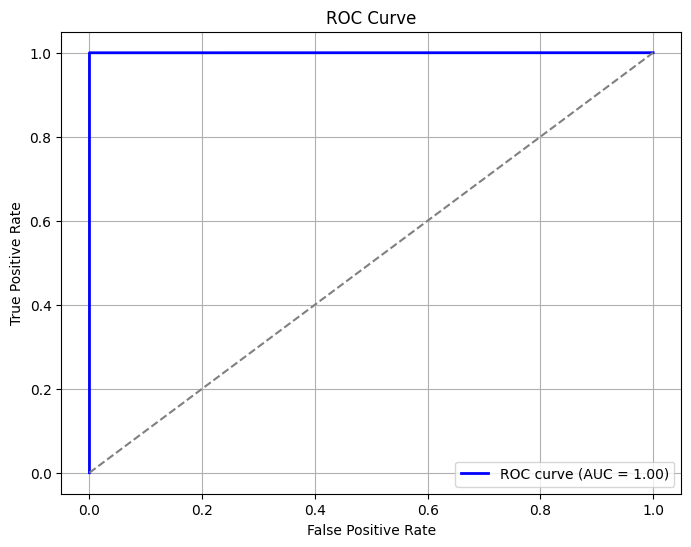

In [23]:
# Evaluate the model
# Accuracy: show the proportion of the correct prediction in the total predictions.
accuracy = accuracy_score(Y_test, Y_pred)
print("Accuracy:", accuracy)

# Confusion matrix: the correct and incorrect prediction by giving details in the types of wrong predictions
cm = confusion_matrix(Y_test, Y_pred)
print("Confusion matrix:\n", cm)

# Plot confusion matrix using seaborn's heatmap
# plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='GnBu')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Calculate precision
precision = precision_score(Y_test, Y_pred, average='binary')
print(f"Precision: {precision:.2f}")

# Calculate recall
recall = recall_score(Y_test, Y_pred, average='binary')
print(f"Recall: {recall:.2f}")

# F1 Score: The harmonic mean of precision and recall, offering a balance between the two metrics.​
f1 = f1_score(Y_test, Y_pred)
print(f"F1 Score: {f1:.2f}")

#UAC
# Compute ROC AUC score
roc_auc = roc_auc_score(Y_test, Y_pred)
print(f"ROC AUC Score: {roc_auc:.2f}")

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(Y_test, Y_pred)

# Compute AUC
roc_auc = roc_auc_score(Y_test, Y_pred)
print(f"ROC AUC: {roc_auc:.2f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()